# Seq2Seq2 visualization: irregular midiseq2 → Lilylet

This notebook loads the paired corpus under `~/data/midi/test202608`, creates a persistent run-local unified vocabulary through the configuration, and inspects aligned crops. Lilylet-containing Seq2Seq2 is intentionally configured with `mark_mode="measure"`.

In [1]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
sys.path.insert(0, str(ROOT))
CONFIG = ROOT / 'configs' / 'midi-translator-irregular-to-lilylet.yaml'
DATA_ROOT = Path.home() / 'data' / 'midi' / 'test202608'
print('repo:', ROOT)
print('data:', DATA_ROOT)


repo: /home/camus/work/deep-starry
data: /home/camus/data/midi/test202608


In [2]:
from starry.utils.config import Configuration
from starry.midi.data.seq2seq2 import Seq2Seq2

# Persistent creation is required so the run-local unifiedSeq2Vocab.json is pinned beside .state.yaml.
config = Configuration.createOrLoad(str(CONFIG))
data_root = Path(os.environ['DATA_DIR']).expanduser() / config['data.root']
print('run:', config.dir)
print('data root:', data_root)
print('vocab:', config['data.args.vocab_path'])
train, val = Seq2Seq2.load(str(data_root), config['data.args'], config['data.splits'],
                           args_variant=config['data.args_variant'])
print('train samples:', len(train), '| validation samples:', len(val))

run: /home/camus/data/training/midi/20260814-midi-translator-irregular-to-lilylet
data root: /home/camus/data/midi/test202608
vocab: /home/camus/data/training/midi/20260814-midi-translator-irregular-to-lilylet/unifiedSeq2Vocab.json
train samples: 90 | validation samples: 9


In [3]:
# Inspect one deterministic validation crop.
case = val.describe(0)
print('sample:', case['name'])
print('source measures:', case['source_measures'])
print('target measures:', case['target_measures'])
print('source range:', case['source_range'], '| target range:', case['target_range'])
print('tokens:', len(case['ids']), '| separator:', case['sep'])
print('source/target formats:', config['data.args.source_format'], '->', config['data.args.target_format'])


sample: 00000121f169d244fdf624d9cc9b7910
source measures: [58, 59]
target measures: [58, 59]
source range: (57, 59) | target range: (57, 59)
tokens: 989 | separator: 650
source/target formats: midiseq2 -> lilylet


In [4]:
# Corpus-level crop lengths and source/target measure counts.
rows = [val.describe(i) for i in range(len(val))]
lengths = np.array([len(r['ids']) for r in rows])
src_measures = np.array([len(r['source_measures']) for r in rows])
tgt_measures = np.array([len(r['target_measures']) for r in rows])
print('length min/median/max:', lengths.min(), int(np.median(lengths)), lengths.max())
print('source measures min/median/max:', src_measures.min(), int(np.median(src_measures)), src_measures.max())
print('target measures min/median/max:', tgt_measures.min(), int(np.median(tgt_measures)), tgt_measures.max())


length min/median/max: 160 934 1715
source measures min/median/max: 2 3 8
target measures min/median/max: 2 3 8


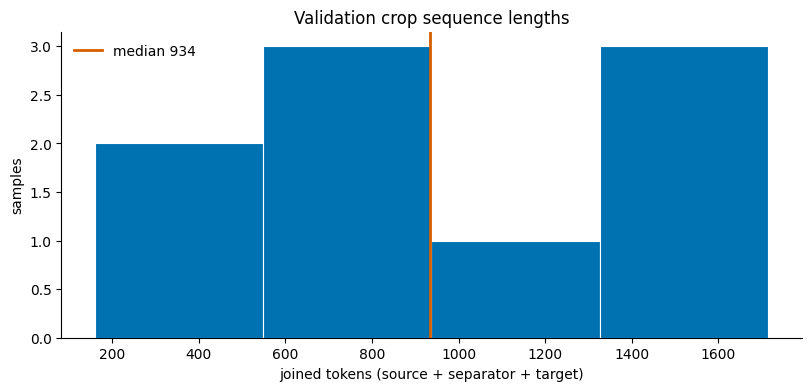

In [5]:
# One-axis distribution view: sequence length is the quantity of interest.
fig, ax = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
ax.hist(lengths, bins=min(12, max(4, len(lengths)//2)), color='#0072B2', edgecolor='white', linewidth=0.8)
ax.axvline(np.median(lengths), color='#D55E00', linewidth=2, label=f'median {np.median(lengths):.0f}')
ax.set(title='Validation crop sequence lengths', xlabel='joined tokens (source + separator + target)', ylabel='samples')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.show()


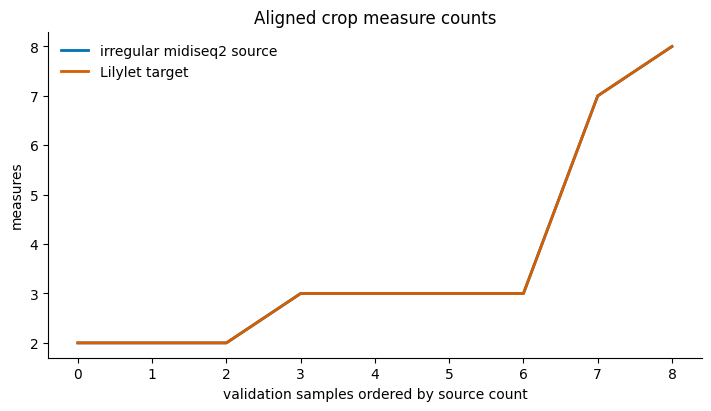

In [6]:
# Paired measure-count comparison. Identity is encoded by position, not color alone.
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
order = np.argsort(src_measures)
x = np.arange(len(rows))
ax.plot(x, src_measures[order], color='#0072B2', linewidth=2, label='irregular midiseq2 source')
ax.plot(x, tgt_measures[order], color='#D55E00', linewidth=2, label='Lilylet target')
ax.set(title='Aligned crop measure counts', xlabel='validation samples ordered by source count', ylabel='measures')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.show()


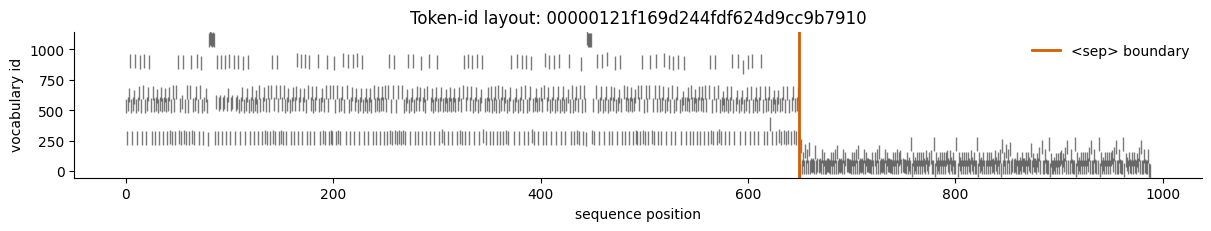

In [7]:
# Token-id strip for the selected crop. The separator marks the supervision boundary.
ids = np.asarray(case['ids'])
fig, ax = plt.subplots(figsize=(12, 2.2), constrained_layout=True)
ax.plot(np.arange(len(ids)), ids, linestyle='', marker='|', markersize=10, color='#333333', alpha=.65)
ax.axvline(case['sep'] - .5, color='#D55E00', linewidth=2, label='<sep> boundary')
ax.set(title=f"Token-id layout: {case['name']}", xlabel='sequence position', ylabel='vocabulary id')
ax.legend(frameon=False, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.show()


## Notes

- The source and target are aligned through `metadata/measures.json`; directives are omitted from content tokens.
- The dataset implementation rejects `tick` mode and `absolute` positions for mixed Lilylet runs.
- The final cell prints a compact textual preview because raw Lilylet text is more useful than rendering it as a chart.

In [8]:
def mixed_text_preview(value, measure_numbers, format_name, limit=1200):
    if format_name == 'lilylet':
        # Mixed Lilylet values are lists indexed by one-based source measure number.
        text = ''.join(value[number - 1] for number in measure_numbers)
    else:
        # Mixed midiseq2 values are parsed _File objects; select whole played measures.
        lines = []
        for number in measure_numbers:
            start = value.marks[number - 1][0]
            end = value.marks[number][0] if number < len(value.marks) else len(value.lines)
            lines.extend(value.lines[start:end])
        text = ''.join(lines)
    return text[:limit]

source_format = config['data.args.source_format']
target_format = config['data.args.target_format']
print('source preview:')
print(mixed_text_preview(case['source'], case['source_measures'], source_format))
print('target preview:')
print(mixed_text_preview(case['target'], case['target_measures'], target_format))

source preview:
@measure 58E2@tick 0note_on C3 #3e $54E2note_on C4 #2f $53E3note_on C1 #4a $4fE3note_on #56 $51E2note_on C2 #47 $4eEbnote_off #51E5note_off C4 #35E3note_off C2 #45E8note_off C3 #3cEdnote_off C1 #48E020 E2note_off #56E7@tick 80note_on #58 $4cE010 Ebcontrol_change #02 $50E030 E3note_off #58E3@tick 160note_on #56 $4eE030 Ea@tick 240note_on C1 #4a $55E3note_on #59 $41E4note_off C3 #3eE1set_tempo 1 e 8 4 8 0control_change #02 $50control_change C1 #02 $50control_change C2 #02 $50note_on C3 #3e $52control_change C3 #02 $50control_change C4 #02 $50E1note_on C2 #47 $43E1note_on C4 #3b $4fE4note_off C1 #4aE1note_off C4 #2fE2note_off #56E5note_off C2 #47E010 E7note_off #59E6@tick 320note_on #58 $4dE010 Ef@tick 400note_on #59 $49E9note_off #58E010 Eenote_off #59E3note_off C4 #3bE1note_off C2 #47@tick 480note_on C2 #4a $5enote_on C3 #41 $58note_on C4 #3e $53E2note_on #56 $4enote_off C1 #4aE3note_on C1 #4d $52Eanote_off C3 #3eE010 E6@tick 560note_on #58 $4cE7note_off #56E020@tick 640